# 🧠 Generative Adversarial Network (GAN) on MNIST

This notebook demonstrates a simple GAN trained on the MNIST dataset.

## What is a GAN?

A GAN consists of two neural networks:
- **Generator**: Creates fake images
- **Discriminator**: Tries to distinguish real vs fake images

They compete against each other:
- Generator improves to fool the discriminator
- Discriminator improves to detect fakes

## Goal
Generate realistic handwritten digits.

In [1]:
# Install dependencies (Colab usually has these)
!pip install tensorflow matplotlib

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

## Loading MNIST Dataset

- 28x28 grayscale handwritten digits
- Normalized between -1 and 1 for GAN training

In [2]:
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1]

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## Generator Network

- Takes random noise as input
- Outputs fake images

In [3]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Discriminator Network

- Classifies images as REAL (1) or FAKE (0)
- This is where "accuracy" comes from

In [4]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[28,28,1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Loss Functions

- Binary Crossentropy used
- Generator wants discriminator to output "1" for fake images

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

## Training Step

- Generator creates fake images
- Discriminator evaluates both real & fake
- Both networks update weights

In [6]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # Accuracy (real vs fake classification)
    real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))
    fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))
    acc = (real_acc + fake_acc) / 2

    return gen_loss, disc_loss, acc

## Training Loop

We track:
- Generator Loss
- Discriminator Loss
- Discriminator Accuracy (target ~80%+ early)

In [7]:
EPOCHS = 10

for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        g_loss, d_loss, acc = train_step(image_batch)

    print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}, Accuracy: {acc:.4f}")

Epoch 1, Gen Loss: 0.7110, Disc Loss: 1.2798, Accuracy: 0.6315
Epoch 2, Gen Loss: 1.2569, Disc Loss: 0.9828, Accuracy: 0.7812
Epoch 3, Gen Loss: 0.8135, Disc Loss: 1.2528, Accuracy: 0.6621
Epoch 4, Gen Loss: 1.0937, Disc Loss: 0.8945, Accuracy: 0.8867
Epoch 5, Gen Loss: 1.1939, Disc Loss: 0.9537, Accuracy: 0.8516
Epoch 6, Gen Loss: 0.7364, Disc Loss: 1.4545, Accuracy: 0.5065
Epoch 7, Gen Loss: 0.8469, Disc Loss: 1.2157, Accuracy: 0.6517
Epoch 8, Gen Loss: 0.9430, Disc Loss: 1.1002, Accuracy: 0.7493
Epoch 9, Gen Loss: 0.6310, Disc Loss: 1.6907, Accuracy: 0.4095
Epoch 10, Gen Loss: 0.7750, Disc Loss: 1.4412, Accuracy: 0.5345


## Generate Sample Images

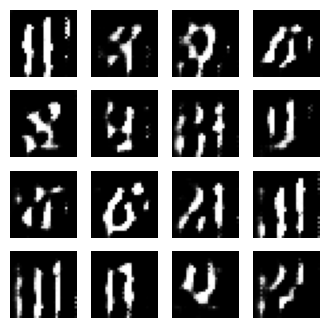

In [8]:
def generate_images(model):
    noise = tf.random.normal([16, 100])
    predictions = model(noise, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.show()

generate_images(generator)

In [9]:
# Generate fake images using the generator
num_samples = 1000
noise = tf.random.normal([num_samples, 100])
fake_images = generator(noise, training=False)

# Take some real images for comparison
real_images = train_images[:num_samples]

# --- Compare average brightness of images ---
real_mean = tf.reduce_mean(real_images)
fake_mean = tf.reduce_mean(fake_images)
mean_diff = tf.abs(real_mean - fake_mean)

# --- Compare variation in pixel values ---
real_std = tf.math.reduce_std(real_images)
fake_std = tf.math.reduce_std(fake_images)
std_diff = tf.abs(real_std - fake_std)

# --- Check how confident discriminator is ---
real_preds = discriminator(real_images, training=False)
fake_preds = discriminator(fake_images, training=False)

real_conf = tf.reduce_mean(real_preds)   # should be close to 1
fake_conf = tf.reduce_mean(fake_preds)   # should be close to 0

# --- Check diversity of generated images ---
diversity = tf.math.reduce_variance(fake_images)

# --- Print results ---
print("GAN Evaluation:\n")

print("Mean Difference:", float(mean_diff))        # lower is better
print("Std Difference:", float(std_diff))          # lower is better

print("\nReal Confidence:", float(real_conf))      # ~1 is good
print("Fake Confidence:", float(fake_conf))        # ~0 is good

print("\nDiversity:", float(diversity))            # higher is better

GAN Evaluation:

Mean Difference: 0.022412240505218506
Std Difference: 0.033008575439453125

Real Confidence: 0.5362365245819092
Fake Confidence: 0.5303834676742554

Diversity: 0.4138171970844269
